# ==========================================
# CELL 1: Environment Setup
# ==========================================
# We need to install the core libraries.
# 'transformers' is Hugging Face's main library containing all the models.
# 'datasets' gives us access to thousands of public datasets.
# 'torch' is the PyTorch backend that actually performs the matrix operations.

In [1]:
!pip install -q transformers datasets torch

print("Environment setup complete! Ready to build some AI.")

Environment setup complete! Ready to build some AI.


# ==========================================
# CELL 2: The "Magic" Pipeline
# ==========================================
# The 'pipeline' is Hugging Face's highest-level tool.
# It abstracts away the complex PyTorch math and handles 3 things automatically:
# 1. Preprocessing (turning raw text into numbers)
# 2. Forward Pass (pushing numbers through the neural network)
# 3. Postprocessing (turning the network's output back into human-readable labels)


In [2]:
from transformers import pipeline

# We instantiate a sentiment-analysis pipeline.
# By default, this downloads a pre-trained DistilBERT model.
classifier = pipeline("sentiment-analysis")

# @title Enter Sample Reviews:
review_1 = " I hate biology.  I love biology." #@param {type:"string"}
review_2 = "The food was alright, the service was awful, and I will always go back." #@param {type:"string"}

# We combine the individual strings into a standard list manually
texts = [review_1, review_2]


# Pass the text directly into our classifier
results = classifier(texts)

# Display the results clearly for the students
for text, result in zip(texts, results):
    print(f"Input: {text}")
    print(f"AI Prediction: {result['label']} (Confidence: {result['score']:.4f})\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Input:  I hate biology.  I love biology.
AI Prediction: POSITIVE (Confidence: 0.9952)

Input: The food was alright, the service was awful, and I will always go back.
AI Prediction: POSITIVE (Confidence: 0.7402)



# ==========================================
# CELL 3: Opening the Black Box - Tokenization
# ==========================================
# How does a neural network understand words if it can only compute numbers?
# The answer is Tokenization. We must slice strings into chunks (tokens)
# and assign each chunk a unique integer ID from a giant dictionary.

In [3]:


from transformers import AutoTokenizer

# We load the tokenizer specifically designed for a popular model called BERT.
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_sentence = "Neural networks map words to numbers." #@param {type:"string"}

# Step 1: Slice the sentence into sub-words (tokens)
tokens = tokenizer.tokenize(sample_sentence)
print(f"1. Words broken into tokens:\n{tokens}\n")

# Step 2: Map each token to its unique ID from the model's vocabulary
token_ids = tokenizer.convert_tokens_to_ids(tokens)
print(f"2. Tokens mapped to integer IDs:\n{token_ids}\n")

# Step 3: Do it all at once and return PyTorch tensors ('pt')
# This is how we actually prepare data for the model in practice.
encoded_input = tokenizer(sample_sentence, return_tensors="pt")
print(f"3. Full dictionary ready for the PyTorch model:\n{encoded_input}")

# Notice two things in the output dictionary:
# 'input_ids' are the actual token integers we just saw.
# 'attention_mask' tells the model which tokens are real words (1) and which are just empty padding (0).

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

1. Words broken into tokens:
['neural', 'networks', 'map', 'words', 'to', 'numbers', '.']

2. Tokens mapped to integer IDs:
[15756, 6125, 4949, 2616, 2000, 3616, 1012]

3. Full dictionary ready for the PyTorch model:
{'input_ids': tensor([[  101, 15756,  6125,  4949,  2616,  2000,  3616,  1012,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1]])}


# ==========================================
# CELL 4: Phase 3 - The PyTorch Connection
# ==========================================
# We used a 'pipeline' before to hide the math. Now, let's do it manually.
# We will load the exact same model our pipeline used, but this time
# as a raw PyTorch neural network.

In [4]:

from transformers import AutoModelForSequenceClassification
import torch

# Load the pre-trained weights for the sentiment model
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# 1. Prepare the text just like before
text = "Learning AI is incredibly frustrating and difficult!" #@param {type:"string"}
inputs = tokenizer(text, return_tensors="pt")

# 2. The Forward Pass (No magic, just matrix multiplication)
# We pass our PyTorch tensors into the model.
# We use torch.no_grad() because we are only predicting, not training (which saves memory).
with torch.no_grad():
    outputs = model(**inputs)

# 3. Understanding Logits
# The model doesn't output "Positive" or "Negative".
# It outputs raw mathematical scores called 'logits'.
logits = outputs.logits
print(f"Raw Model Outputs (Logits): {logits}\n")

# 4. Converting Logits to Probabilities
# We use a math function called 'Softmax' to squash the raw scores into percentages that add up to 100%.
probabilities = torch.nn.functional.softmax(logits, dim=-1)
print(f"Probabilities (Negative vs Positive): {probabilities}\n")

# 5. Getting the Final Answer
# We find which percentage is higher using argmax (index 0 is Negative, index 1 is Positive).
predicted_class_id = probabilities.argmax().item()
print(f"Final Prediction: {model.config.id2label[predicted_class_id]}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Raw Model Outputs (Logits): tensor([[ 3.8464, -3.1657]])

Probabilities (Negative vs Positive): tensor([[9.9910e-01, 9.0005e-04]])

Final Prediction: NEGATIVE


# ==========================================
# CELL 5: Phase 4 - Building a Web Interface (Gradio)
# ==========================================
# Now that we know how the model works, let's build a UI for it.
# Gradio allows us to create web apps directly inside Colab notebooks.

In [5]:


!pip install -q gradio

import gradio as gr
from transformers import pipeline

# We'll use our friendly pipeline again for the web app
classifier = pipeline("sentiment-analysis")

# Gradio needs a simple Python function to wrap around our model.
def analyze_sentiment(user_input):
    # Pass the text to our model
    result = classifier(user_input)[0]

    # Format a nice string to return to the screen
    label = result['label']
    confidence = round(result['score'] * 100, 2)
    return f"Prediction: {label} (Confidence: {confidence}%)"

# Build the interface
# We tell it we want a text box for input, and text for output.
interface = gr.Interface(
    fn=analyze_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Type a sentence here..."),
    outputs="text",
    title="My First AI Sentiment Analyzer",
    description="Type any sentence to see if the AI thinks it is POSITIVE or NEGATIVE!"
)

# Launch it! This will create an interactive widget right below this cell.
interface.launch()

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7a8bdd591de5ae0568.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# ==========================================
# CELL 6 : Text Generation with GPT-2 + Gradio
# ==========================================
# Instead of classifying text, we now load an autoregressive language model (GPT-2).
# The model predicts the next token, one by one, based on your prompt.

In [7]:
import gradio as gr
from transformers import pipeline

# 1. Load the text-generation pipeline using the standard 124M parameter GPT-2
generator = pipeline("text-generation", model="gpt2")

# 2. Define the generation function
def generate_text(prompt, max_tokens, temperature):
    """
    Args:
        prompt (str): The starting text input by the student.
        max_tokens (int): How many new words/tokens the model is allowed to generate.
        temperature (float): Controls randomness/creativity.
            - Low (< 0.5): Conservative, repetitive, predictable.
            - High (> 1.0): Creative, chaotic, surprising.b
    """
    if not prompt.strip():
        return "Please enter a starting prompt!"

    # Run the generator
    results = generator(
        prompt,
        max_new_tokens=int(max_tokens),
        temperature=float(temperature),
        do_sample=True,             # Required for temperature to take effect
        top_k=50,                   # Only consider the top 50 most likely next words
        top_p=0.95,                 # Nucleus sampling: keep top 95% probability mass
        pad_token_id=50256          # Set pad token ID to avoid warning messages in GPT-2
    )

    # Extract generated text
    return results[0]["generated_text"]

# 3. Build the Gradio UI with interactive sliders
interface = gr.Interface(
    fn=generate_text,
    inputs=[
        gr.Textbox(
            lines=3,
            placeholder="Once upon a time in a world run by robots...",
            label="Prompt / Starting Sentence"
        ),
        gr.Slider(
            minimum=10,
            maximum=150,
            value=50,
            step=10,
            label="Max New Tokens (Length)"
        ),
        gr.Slider(
            minimum=0.1,
            maximum=1.5,
            value=0.8,
            step=0.1,
            label="Temperature (Creativity)"
        )
    ],
    outputs=gr.Textbox(lines=6, label="AI Continuation"),
    title="🤖 GPT-2 Story Generator",
    description="Type a starting prompt, tweak the creativity (temperature), and watch GPT-2 continue the text!"
)

# Launch the app and generate a public share link
interface.launch(share=True)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9714db5c3ec009e505.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# ==========================================
# CELL 7: Peeking at the Next-Token Probabilities
# ==========================================
# Instead of letting the model generate the text automatically,
# we pause the process right before the final decision is made.
# We will extract the raw logits, convert them to percentages,
# and rank the top 5 most likely next words.


In [15]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# 1. Load the model and tokenizer (we explicitly need CausalLM for text generation)
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# 2. Define our starting sentence
# Feel free to change this! A good prompt to try: "The capital of France is"
prompt = "I opened the book and started to"  #@param {type:"string"}
print(f"Prompt: '{prompt}'\n")
print("-" * 40)

# Convert the text into tensor IDs
inputs = tokenizer(prompt, return_tensors="pt")

# 3. The Forward Pass
with torch.no_grad():
    outputs = model(**inputs)

# outputs.logits shape is (Batch Size, Sequence Length, Vocabulary Size)
# We only care about the predictions for the VERY LAST token in our sequence,
# because that token contains the predictions for the next word.
# '0' gets the first (and only) batch. '-1' gets the last token in the sequence.
next_token_logits = outputs.logits[0, -1, :]

# 4. Softmax Conversion
# The logits are raw, unbounded numbers (can be negative or huge).
# Softmax squashes them into a probability distribution that sums exactly to 1.0 (or 100%).
probabilities = torch.nn.functional.softmax(next_token_logits, dim=-1)

# 5. Extract the Top 5 probabilities and their corresponding vocabulary indices
top_5_probs, top_5_indices = torch.topk(probabilities, 5)

# 6. Display the results clearly
print("Top 5 Predicted Next Tokens:")
for i in range(5):
    # Convert the integer ID back into a readable word/subword
    token_id = top_5_indices[i].item()
    token_text = tokenizer.decode([token_id])

    # Convert the probability to a percentage
    prob_percentage = top_5_probs[i].item() * 100

    # Repr() is used to show exact characters, including spaces (like '\n' or ' ')
    print(f"{i+1}. {repr(token_text):<10} -> {prob_percentage:.2f}%")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Prompt: 'I opened the book and started to'

----------------------------------------
Top 5 Predicted Next Tokens:
1. ' read'    -> 25.93%
2. ' write'   -> 8.50%
3. ' think'   -> 4.54%
4. ' look'    -> 3.39%
5. ' talk'    -> 2.82%


# ==========================================
# CELL 8: Generative AI for Images (Stable Diffusion)
# ==========================================
# We move from text (NLP) to images (Computer Vision).
# The library we use is 'diffusers', which is specialized for diffusion models.
# The previous cells were all about transformers; now we use the companion diffusers library.

✅ GPU found! Image generation will be fast.
Loading runwayml/stable-diffusion-v1-5... (this may take 1-2 minutes the first time due to download)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Pipeline loaded and ready!
Generating image for prompt: 'A 1990s Red Ferrari'...


  0%|          | 0/30 [00:00<?, ?it/s]

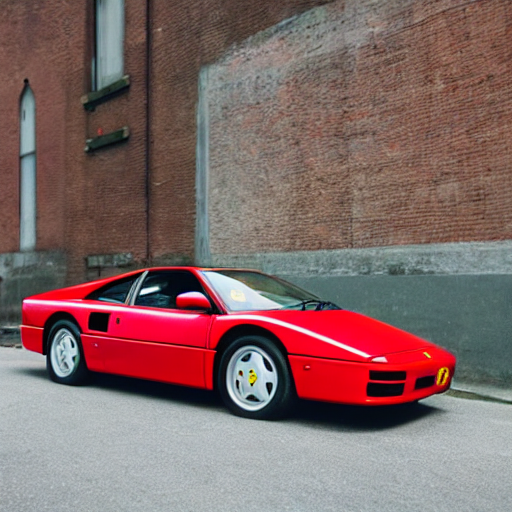

Image generation complete.


In [17]:

# 1. Install the specialized diffusion library and 'accelerate'
# (Accelerate helps run large models efficiently on GPUs)
!pip install -q diffusers transformers accelerate

import torch
# We are using Stable Diffusion v1.5, which is a classic, stable, and relatively
# fast model that works well on Colab's standard T4 GPU.
from diffusers import StableDiffusionPipeline
from PIL import Image

# 2. Check for GPU (CUDA) availability.
# Image generation is massively parallelizable; it is incredibly slow on a CPU.
if not torch.cuda.is_available():
    print("❌ CAUTION: GPU not found. Check Runtime -> Change runtime type -> Hardware accelerator.")
    device = "cpu"
else:
    print("✅ GPU found! Image generation will be fast.")
    device = "cuda"

# 3. Load the Model Pipeline.
# We download the 'runwayml/stable-diffusion-v1-5' model and send it to the GPU ('cuda').
# 'torch.float16' is a data type (half-precision) that uses less GPU memory,
# making the process faster without a visible loss in image quality.
model_id = "runwayml/stable-diffusion-v1-5"
print(f"Loading {model_id}... (this may take 1-2 minutes the first time due to download)")
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)
print("Pipeline loaded and ready!")

# 4. Generate the Image.
# The user (or student) prompt. Be descriptive!
# Prompt ideas: "A futuristic city in the style of Van Gogh", "A fluffy cyber-cat on a surfboard"
prompt = "A 1990s Red FerrariA photographic portrait of an astronaut on a distant planet, detailed spacesuit, red rocky environment, hyperrealistic, dramatic lighting." #@param {type:"string"}
print(f"Generating image for prompt: '{prompt}'...")

# This executes the model's 'forward pass'. Stable Diffusion takes
# several iterative 'steps' to turn random noise into the final image.
with torch.no_grad():
    result = pipe(prompt, num_inference_steps=30) # 30-50 steps is standard

# The pipeline returns an object containing 'images' (a list of PIL images)
# and 'nsfw_content_detected' (a list of booleans indicating potential unsafe content).

# 5. Handle the result.
# Check if the model's built-in safety checker (a key feature of Hugging Face pipeline)
# was triggered, which would result in a black or distorted image.
if result.nsfw_content_detected and result.nsfw_content_detected[0]:
    print("⛔ Safety Checker Triggered: The prompt may have requested unsafe content.")
else:
    # Display the final image directly in the notebook output.
    image = result.images[0]
    display(image)
    print("Image generation complete.")

# ==========================================
# CELL 9: Multimodal AI Chain (Text -> Image)
# ==========================================
# Combine GPT-2 and Stable Diffusion into an automated creative pipeline!

[transformers] Both `max_new_tokens` (=25) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 GPT-2 came up with this prompt:
"A red rose blooms above the front of Tohoku Bay."

🎨 Stable Diffusion is painting the scene...


  0%|          | 0/25 [00:00<?, ?it/s]

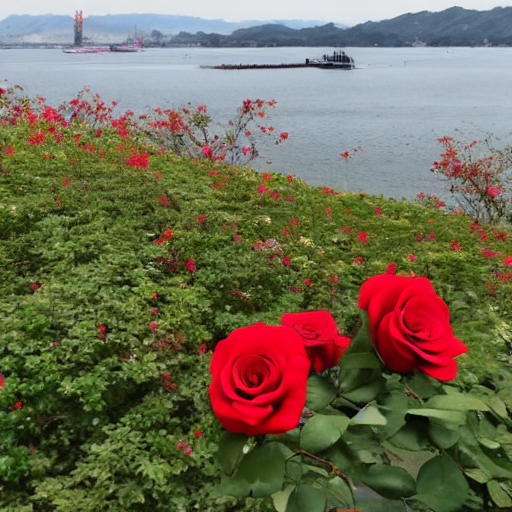

In [23]:
import torch

# 1. Ask GPT-2 to describe a scene
prompt_starter = "A red rose" #@param {type:"string"}
story_result = generator(
    prompt_starter,
    max_new_tokens=25,
    temperature=0.85,
    do_sample=True,
    pad_token_id=50256
)

generated_prompt = story_result[0]["generated_text"]
print(f"🤖 GPT-2 came up with this prompt:\n\"{generated_prompt}\"\n")

# 2. Feed GPT-2's output directly into Stable Diffusion
print("🎨 Stable Diffusion is painting the scene...")
with torch.no_grad():
    image_result = pipe(generated_prompt, num_inference_steps=25)

display(image_result.images[0])

In [31]:
# ==========================================
# CELL 10: Zero-Shot Classification
# ==========================================
# Zero-shot lets you classify text into ANY custom categories on the fly!

import ast

zero_shot = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

text_to_test = "Taylor Swift got married recently." #@param {type:"string"}
custom_labels_str = "[\"computer science\",  \"music\", \"online retail\", \"mathematics\", \"cooking recipe\", \"extreme sports\", \"gaming\"]" #@param {type:"string"}
custom_labels = ast.literal_eval(custom_labels_str)

prediction = zero_shot(text_to_test, candidate_labels=custom_labels)

print(f"Text: \"{text_to_test}\"\n")
for label, score in zip(prediction['labels'], prediction['scores']):
    print(f"• {label:<18}: {score*100:.1f}%")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Text: "Taylor Swift got married recently."

• music             : 86.4%
• cooking recipe    : 2.9%
• extreme sports    : 2.8%
• gaming            : 2.3%
• online retail     : 2.1%
• mathematics       : 1.9%
• computer science  : 1.6%
